In [57]:
import pandas as pd
from datetime import date
from pathlib import Path
import matplotlib.pyplot as plt

In [58]:
START_DATE = date(2018, 1, 1)
END_DATE = date(2022, 12, 31)

COVARIATE = "heat_index" # temp or heat_index

SPLIT = 0.7
FORMULA_NUM = 5

PLOT_OUTPUT_FILE = Path(f"../plots/predictions/predictions_{COVARIATE}_{START_DATE}_{END_DATE}_{SPLIT}_{FORMULA_NUM}.png")
PLOT_DATA_FOLDER = Path(f"../data/{COVARIATE}/{COVARIATE}_{START_DATE}_{END_DATE}_{SPLIT}_{FORMULA_NUM}")

assert PLOT_DATA_FOLDER.exists(), f"{PLOT_DATA_FOLDER} folder doesn't exist"

In [59]:
x_tick_ts = []
x_tick_years = []
for year in range(START_DATE.year, END_DATE.year+2):
    days_since = (date(year, 1, 1) - START_DATE).days + 1
    x_tick_ts.append(days_since)
    x_tick_years.append(year)

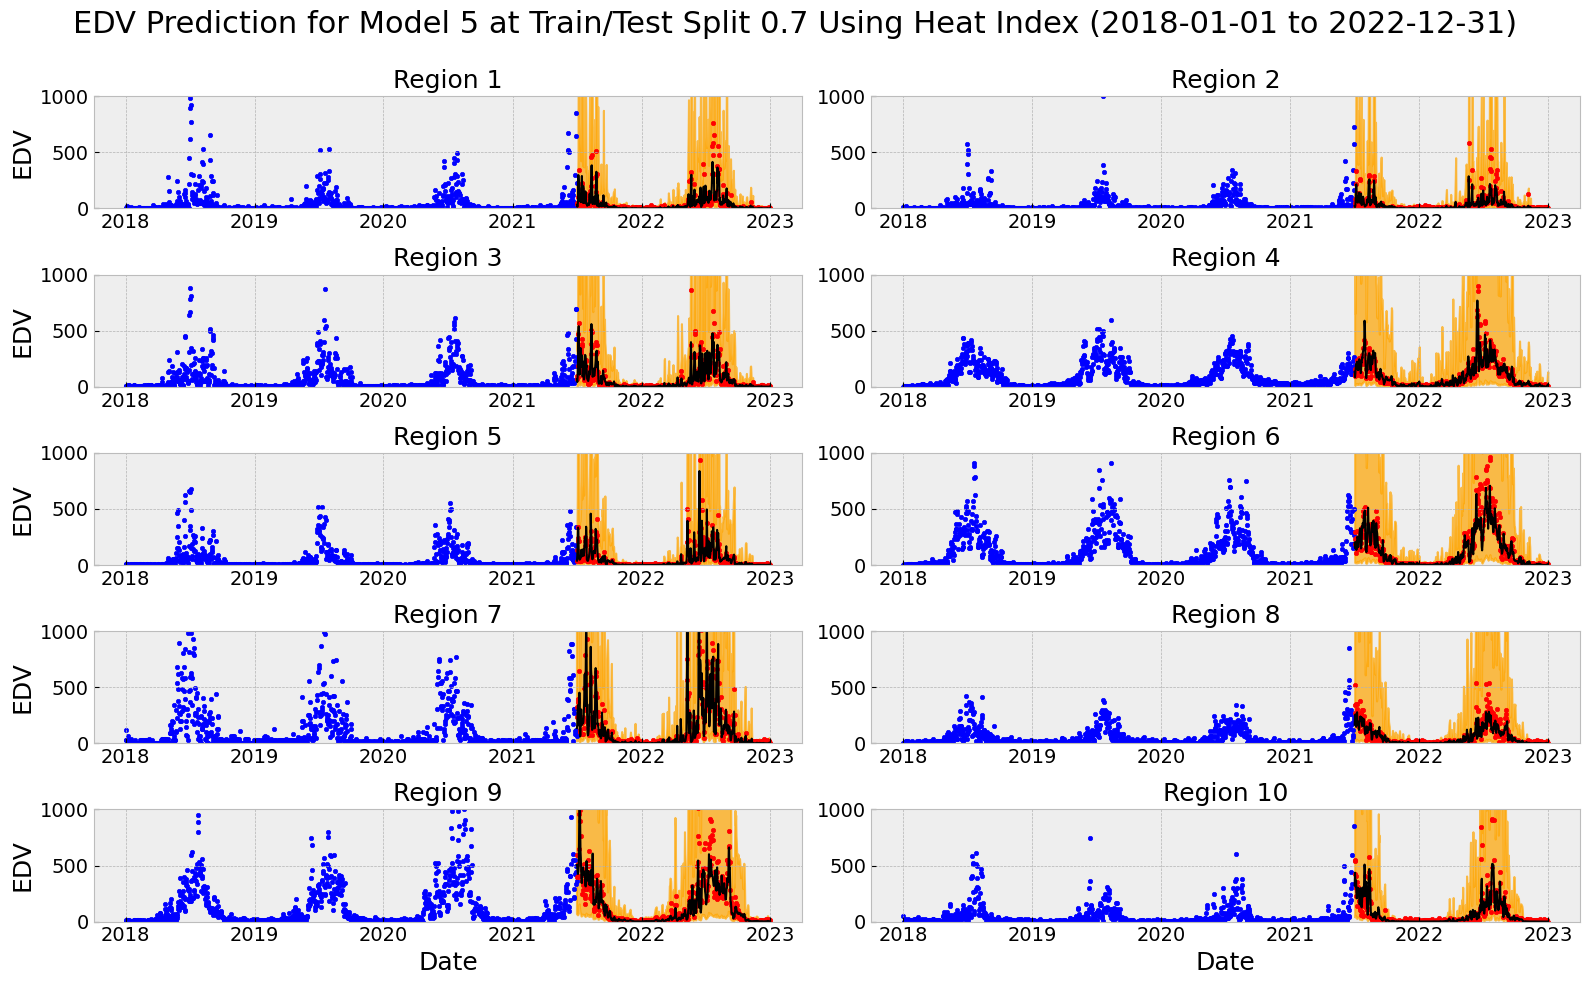

In [60]:
plt.style.use('bmh')
fig, axs = plt.subplots(5, 2, figsize = (16, 10))

covariate_for_title = "Temperature" if COVARIATE == "temp" else "Heat Index"
fig.suptitle(f"EDV Prediction for Model {FORMULA_NUM} at Train/Test Split {SPLIT} Using {covariate_for_title} ({START_DATE} to {END_DATE})", fontsize = 22)


for region in range(1, 11):
    data = pd.read_csv(PLOT_DATA_FOLDER / f"region{region}_data.csv", index_col = 0, usecols = ["t", "region", "ed.visits", "is.train"])
    interval = pd.read_csv(PLOT_DATA_FOLDER / f"region{region}_interval.csv", index_col = 0, usecols = ["t", "pred2", "low", "high"])
    data = data.merge(interval, on = "t", how = "left")
    train = data[data["is.train"]]
    test = data[~data["is.train"]]

    col = (region - 1) % 2
    row = (region - 1) // 2
    ax = axs[row, col]
    
    ax.fill_between(x = test.index, y1 = test["low"], y2 = test["high"], color = "orange", alpha = 0.7, lw = 1.5)
    ax.scatter(x = train.index, y = train["ed.visits"], c = "blue", s = 10)
    ax.scatter(x = test.index, y = test["ed.visits"], c = "red", s = 10)
    ax.plot(test.index, test["pred2"], c = "black", lw = 1.5)

    ax.set_ylim(0, 1000)
    ax.set_xticks(x_tick_ts, x_tick_years)
    ax.tick_params(axis='both', labelsize = 14)
    ax.set_title(f"Region {region}", fontsize = 18)
    if row == 4:
        ax.set_xlabel("Date", fontsize = 18)
    # else:
    #     ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel("EDV", fontsize = 18)
    # else:
    #     ax.set_yticklabels([])


plt.tight_layout(rect=[0, 0, 1, 0.98]) 
fig.savefig(PLOT_OUTPUT_FILE, dpi = 300)